# SVM con el Dataset Wine

Máquinas de Soporte Vectorial (SVM) sobre el dataset **Wine** de scikit-learn.

**Autor:** Gael Rodríguez Jiménez

## Índice
1. Importar librerías y cargar el dataset
2. Revisar la estructura del dataset
3. Trabajar con dos clases y dos variables
4. Separar entrenamiento y prueba
5. Escalar los datos
6. Entrenar el primer SVM lineal
7. Explorar el parámetro C
8. Entrenar SVM con kernel RBF
9. Explorar el parámetro gamma
10. Comparar configuraciones de modelos
11. Visualizar la frontera de decisión
12. Revisar los vectores de soporte
13. Comparar entrenamiento vs prueba
14. Extensión opcional: 13 variables y 3 clases

## Paso 1 — Importar librerías y cargar el dataset

**Objetivo:** dejar el entorno listo y el dataset Wine cargado como DataFrame de pandas.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

RANDOM_STATE = 42
plt.rcParams["figure.figsize"] = (7, 5)

# Cargar el dataset y convertirlo en DataFrame
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df["target"] = wine.target

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


## Paso 2 — Revisar la estructura del dataset

**Objetivo:** comprender la distribución del dataset antes de modelar.

*Resultado esperado:* shape `(178, 14)`, tres clases: class_0 (59), class_1 (71), class_2 (48).

In [2]:
print("Shape:", df.shape)
print("Clases:", wine.target_names)
print("\nMuestras por clase:")
print(df["target"].value_counts().sort_index())

print("\nVariables disponibles:")
for i, nombre in enumerate(wine.feature_names):
    print(f"  {i:2d}. {nombre}")

Shape: (178, 14)
Clases: ['class_0' 'class_1' 'class_2']

Muestras por clase:
target
0    59
1    71
2    48
Name: count, dtype: int64

Variables disponibles:
   0. alcohol
   1. malic_acid
   2. ash
   3. alcalinity_of_ash
   4. magnesium
   5. total_phenols
   6. flavanoids
   7. nonflavanoid_phenols
   8. proanthocyanins
   9. color_intensity
  10. hue
  11. od280/od315_of_diluted_wines
  12. proline


## Paso 3 — Trabajar con dos clases y dos variables

Para poder visualizar la frontera de decisión en 2D, se filtra a las clases **0 y 1**
y a las variables **alcohol** e **color_intensity**.

*Resultado esperado:* 130 filas.

In [3]:
# Filtrar las clases 0 y 1
df_2c = df[df["target"].isin([0, 1])].copy()
print("Filas tras filtrar:", df_2c.shape[0])   # esperado: 130

# Seleccionar las dos variables
FEATURES = ["alcohol", "color_intensity"]
X = df_2c[FEATURES].values
y = df_2c["target"].values

print("X:", X.shape, "| y:", y.shape)
print("Distribución de clases:", np.bincount(y))

Filas tras filtrar: 130
X: (130, 2) | y: (130,)
Distribución de clases: [59 71]


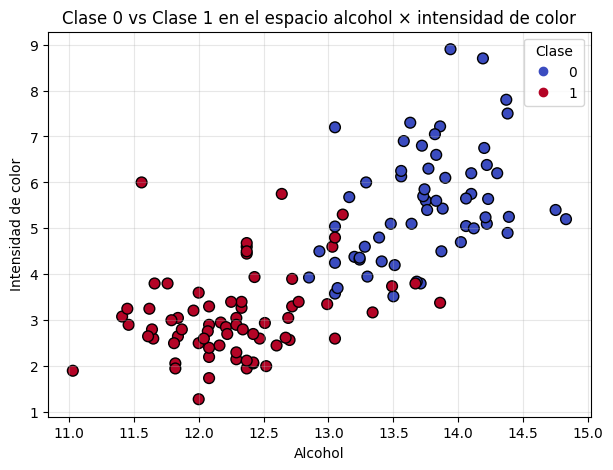

In [4]:
# Graficar los datos originales
plt.figure()
sc = plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k", s=60)
plt.xlabel("Alcohol")
plt.ylabel("Intensidad de color")
plt.title("Clase 0 vs Clase 1 en el espacio alcohol × intensidad de color")
plt.legend(*sc.legend_elements(), title="Clase")
plt.grid(alpha=0.3)
plt.show()

## Paso 4 — Separar entrenamiento y prueba

`stratify=y` conserva la proporción de clases en ambos conjuntos.

*Resultado esperado:* `X_train (104, 2)` y `X_test (26, 2)`.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_test: ", X_test.shape, "| y_test: ", y_test.shape)
print("Proporción train:", np.bincount(y_train) / len(y_train))
print("Proporción test: ", np.bincount(y_test) / len(y_test))

X_train: (104, 2) | y_train: (104,)
X_test:  (26, 2) | y_test:  (26,)
Proporción train: [0.45192308 0.54807692]
Proporción test:  [0.46153846 0.53846154]


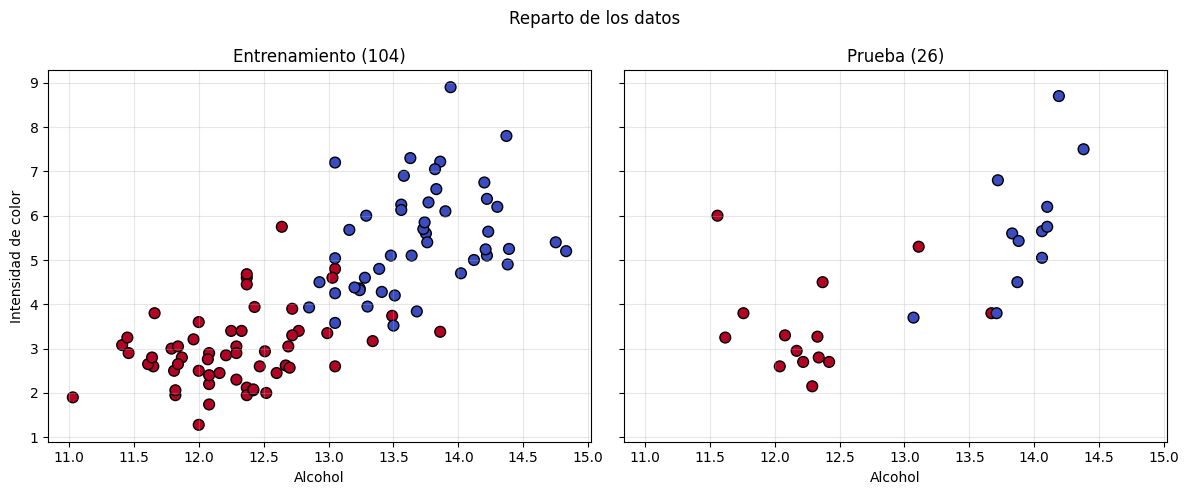

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

for ax, (Xi, yi, titulo) in zip(
    axes,
    [(X_train, y_train, "Entrenamiento (104)"), (X_test, y_test, "Prueba (26)")],
):
    ax.scatter(Xi[:, 0], Xi[:, 1], c=yi, cmap="coolwarm", edgecolor="k", s=60)
    ax.set_title(titulo)
    ax.set_xlabel("Alcohol")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Intensidad de color")
plt.suptitle("Reparto de los datos")
plt.tight_layout()
plt.show()

## Paso 5 — Escalar los datos

SVM es muy sensible a la escala porque trabaja con distancias.

> **Nunca** uses `fit_transform()` sobre los datos de prueba: eso provoca fuga de
> información (*data leakage*). El scaler se ajusta **solo** con entrenamiento.

In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # ajusta y transforma
X_test_scaled = scaler.transform(X_test)         # solo transforma

print("Media train (~0):", X_train_scaled.mean(axis=0).round(6))
print("Desv. train (~1):", X_train_scaled.std(axis=0).round(6))
print("Media test:      ", X_test_scaled.mean(axis=0).round(4))

Media train (~0): [0. 0.]
Desv. train (~1): [1. 1.]
Media test:       [0.1324 0.2622]


## Paso 6 — Entrenar el primer modelo SVM lineal

*Resultado esperado:* entrenamiento accuracy ~0.923 / F1 ~0.927 · prueba accuracy ~0.885 / F1 ~0.889.

In [8]:
def metricas(y_true, y_pred):
    """Devuelve las cuatro métricas de clasificación binaria en un dict."""
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }


def reporte(nombre, modelo, X_tr, y_tr, X_te, y_te):
    """Imprime métricas de train y test y devuelve ambas como dicts."""
    m_tr = metricas(y_tr, modelo.predict(X_tr))
    m_te = metricas(y_te, modelo.predict(X_te))
    print(f"--- {nombre} ---")
    print("Entrenamiento:", {k: round(v, 3) for k, v in m_tr.items()})
    print("Prueba:       ", {k: round(v, 3) for k, v in m_te.items()})
    return m_tr, m_te

In [9]:
svm_lineal = SVC(kernel="linear", C=1)
svm_lineal.fit(X_train_scaled, y_train)

m_tr_lin, m_te_lin = reporte(
    "SVM lineal (C=1)", svm_lineal,
    X_train_scaled, y_train, X_test_scaled, y_test,
)

y_pred_test_lin = svm_lineal.predict(X_test_scaled)

print("\nMatriz de confusión (prueba):")
print(confusion_matrix(y_test, y_pred_test_lin))

print("\nReporte de clasificación (prueba):")
print(classification_report(y_test, y_pred_test_lin,
                            target_names=["class_0", "class_1"]))

--- SVM lineal (C=1) ---
Entrenamiento: {'accuracy': 0.923, 'precision': 0.962, 'recall': 0.895, 'f1': 0.927}
Prueba:        {'accuracy': 0.885, 'precision': 0.923, 'recall': 0.857, 'f1': 0.889}

Matriz de confusión (prueba):
[[11  1]
 [ 2 12]]

Reporte de clasificación (prueba):
              precision    recall  f1-score   support

     class_0       0.85      0.92      0.88        12
     class_1       0.92      0.86      0.89        14

    accuracy                           0.88        26
   macro avg       0.88      0.89      0.88        26
weighted avg       0.89      0.88      0.88        26



## Paso 7 — Explorar el parámetro C

`C` controla la penalización de los errores de clasificación:

- **C pequeño** -> mayor tolerancia a errores, frontera más suave y generalizable.
- **C grande** -> menor tolerancia, riesgo de ajustarse demasiado al entrenamiento.

In [10]:
filas = []
for C in [0.01, 0.1, 1, 10, 100]:
    modelo = SVC(kernel="linear", C=C).fit(X_train_scaled, y_train)
    m_tr = metricas(y_train, modelo.predict(X_train_scaled))
    m_te = metricas(y_test, modelo.predict(X_test_scaled))
    filas.append({
        "C": C,
        "acc_train": m_tr["accuracy"],
        "acc_test": m_te["accuracy"],
        "precision_test": m_te["precision"],
        "recall_test": m_te["recall"],
        "f1_test": m_te["f1"],
        "n_vectores": modelo.support_vectors_.shape[0],
    })

df_C = pd.DataFrame(filas)
df_C.round(3)

,C,acc_train,acc_test,precision_test,recall_test,f1_test,n_vectores
0,0.01,0.894,0.885,0.923,0.857,0.889,75
1,0.10,0.933,0.885,0.923,0.857,0.889,36
2,1.00,0.923,0.885,0.923,0.857,0.889,23
3,10.00,0.923,0.885,0.923,0.857,0.889,19
4,100.00,0.923,0.885,0.923,0.857,0.889,18


## Paso 8 — Entrenar SVM con kernel RBF

*Resultado esperado:* prueba accuracy ~0.923 · precision 1.0 · F1 ~0.923.

In [11]:
svm_rbf = SVC(kernel="rbf", C=1, gamma="scale")
svm_rbf.fit(X_train_scaled, y_train)

m_tr_rbf, m_te_rbf = reporte(
    "SVM RBF (C=1, gamma=scale)", svm_rbf,
    X_train_scaled, y_train, X_test_scaled, y_test,
)

print("\nMatriz de confusión (prueba):")
print(confusion_matrix(y_test, svm_rbf.predict(X_test_scaled)))

# Comparación directa contra el lineal
comparacion = pd.DataFrame(
    [m_te_lin, m_te_rbf], index=["linear C=1", "rbf C=1 gamma=scale"]
)
print("\nMétricas en prueba:")
comparacion.round(3)

--- SVM RBF (C=1, gamma=scale) ---
Entrenamiento: {'accuracy': 0.933, 'precision': 0.963, 'recall': 0.912, 'f1': 0.937}
Prueba:        {'accuracy': 0.923, 'precision': 1.0, 'recall': 0.857, 'f1': 0.923}

Matriz de confusión (prueba):
[[12  0]
 [ 2 12]]

Métricas en prueba:


,accuracy,precision,recall,f1
linear C=1,0.885,0.923,0.857,0.889
rbf C=1 gamma=scale,0.923,1.000,0.857,0.923


## Paso 9 — Explorar el parámetro gamma

`gamma` controla qué tan **local** es la influencia de cada observación:

- **gamma pequeño** -> influencia amplia, frontera suave.
- **gamma grande** -> influencia local, frontera compleja y riesgo de sobreajuste.

Fíjate en la brecha entre `acc_train` y `acc_test`: si el train sube y el test baja,
estás sobreajustando.

In [12]:
filas = []
for gamma in [0.01, 0.1, 1, 10]:
    modelo = SVC(kernel="rbf", C=1, gamma=gamma).fit(X_train_scaled, y_train)
    m_tr = metricas(y_train, modelo.predict(X_train_scaled))
    m_te = metricas(y_test, modelo.predict(X_test_scaled))
    filas.append({
        "gamma": gamma,
        "acc_train": m_tr["accuracy"],
        "acc_test": m_te["accuracy"],
        "precision_test": m_te["precision"],
        "recall_test": m_te["recall"],
        "f1_test": m_te["f1"],
        "brecha": m_tr["accuracy"] - m_te["accuracy"],
    })

df_gamma = pd.DataFrame(filas)
df_gamma.round(3)

,gamma,acc_train,acc_test,precision_test,recall_test,f1_test,brecha
0,0.01,0.933,0.885,0.923,0.857,0.889,0.048
1,0.10,0.923,0.923,1.000,0.857,0.923,0.000
2,1.00,0.942,0.923,1.000,0.857,0.923,0.019
3,10.00,0.971,0.885,1.000,0.786,0.880,0.087


## Paso 10 — Comparar configuraciones de modelos

Seis combinaciones de kernel, C y gamma evaluadas de forma sistemática.

In [13]:
configuraciones = [
    {"kernel": "linear", "C": 0.1},
    {"kernel": "linear", "C": 1},
    {"kernel": "linear", "C": 10},
    {"kernel": "rbf", "C": 1, "gamma": 0.1},
    {"kernel": "rbf", "C": 1, "gamma": 1},
    {"kernel": "rbf", "C": 10, "gamma": 1},
]

filas = []
for cfg in configuraciones:
    modelo = SVC(**cfg).fit(X_train_scaled, y_train)
    m_tr = metricas(y_train, modelo.predict(X_train_scaled))
    m_te = metricas(y_test, modelo.predict(X_test_scaled))
    filas.append({
        "kernel": cfg["kernel"],
        "C": cfg["C"],
        "gamma": cfg.get("gamma", "-"),
        "acc_train": m_tr["accuracy"],
        "acc_test": m_te["accuracy"],
        "precision_test": m_te["precision"],
        "recall_test": m_te["recall"],
        "f1_test": m_te["f1"],
        "n_vectores": modelo.support_vectors_.shape[0],
    })

df_configs = pd.DataFrame(filas).sort_values("acc_test", ascending=False)
df_configs.round(3)

,kernel,C,gamma,acc_train,acc_test,precision_test,recall_test,f1_test,n_vectores
4,rbf,1.0,1,0.942,0.923,1.000,0.857,0.923,32
3,rbf,1.0,0.1,0.923,0.923,1.000,0.857,0.923,32
5,rbf,10.0,1,0.952,0.923,1.000,0.857,0.923,22
0,linear,0.1,-,0.933,0.885,0.923,0.857,0.889,36
1,linear,1.0,-,0.923,0.885,0.923,0.857,0.889,23
2,linear,10.0,-,0.923,0.885,0.923,0.857,0.889,19


## Paso 11 — Visualizar la frontera de decisión

La función genera una malla densa, la escala con el **mismo** scaler, predice la clase
de cada punto y colorea las regiones resultantes.

In [14]:
def plot_frontera(modelo, X_orig, y_orig, scaler, titulo, ax=None, paso=300):
    """Dibuja la frontera de decisión de un modelo sobre los datos sin escalar."""
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 5))

    # 1. Malla sobre el rango de los datos originales
    margen = 0.5
    x_min, x_max = X_orig[:, 0].min() - margen, X_orig[:, 0].max() + margen
    y_min, y_max = X_orig[:, 1].min() - margen, X_orig[:, 1].max() + margen
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, paso),
        np.linspace(y_min, y_max, paso),
    )

    # 2. Escalar la malla y predecir
    malla = np.c_[xx.ravel(), yy.ravel()]
    Z = modelo.predict(scaler.transform(malla)).reshape(xx.shape)

    # 3. Graficar regiones + datos reales
    ax.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
    ax.contour(xx, yy, Z, colors="k", linewidths=1)
    ax.scatter(X_orig[:, 0], X_orig[:, 1], c=y_orig,
               cmap="coolwarm", edgecolor="k", s=60)

    # Resaltar los vectores de soporte (guardados en espacio escalado)
    sv = scaler.inverse_transform(modelo.support_vectors_)
    ax.scatter(sv[:, 0], sv[:, 1], s=160, facecolors="none",
               edgecolors="lime", linewidths=1.8, label="Vectores de soporte")

    ax.set_xlabel("Alcohol")
    ax.set_ylabel("Intensidad de color")
    ax.set_title(titulo)
    ax.legend(loc="upper left")
    return ax

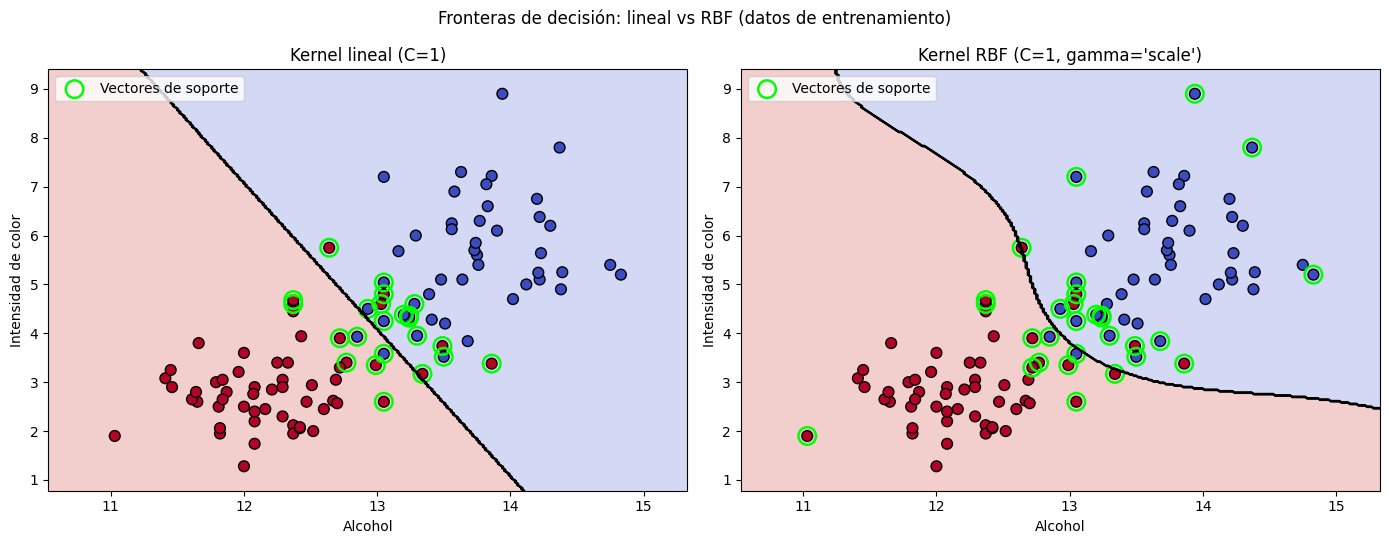

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

plot_frontera(svm_lineal, X_train, y_train, scaler,
              "Kernel lineal (C=1)", ax=axes[0])
plot_frontera(svm_rbf, X_train, y_train, scaler,
              "Kernel RBF (C=1, gamma='scale')", ax=axes[1])

plt.suptitle("Fronteras de decisión: lineal vs RBF (datos de entrenamiento)")
plt.tight_layout()
plt.show()

## Paso 12 — Revisar los vectores de soporte

Los vectores de soporte son las observaciones más cercanas a la frontera y las **únicas**
que determinan su posición.

*Resultado esperado:* lineal 23 `[11, 12]` · RBF 29 `[15, 14]`.

In [16]:
for nombre, modelo in [("Lineal", svm_lineal), ("RBF", svm_rbf)]:
    total = modelo.support_vectors_.shape[0]
    print(f"{nombre:8s} -> por clase: {modelo.n_support_} "
          f"| total: {total} "
          f"| {total / len(X_train):.1%} del entrenamiento")

Lineal   -> por clase: [11 12] | total: 23 | 22.1% del entrenamiento
RBF      -> por clase: [15 14] | total: 29 | 27.9% del entrenamiento


## Paso 13 — Comparar entrenamiento vs prueba

Si el accuracy de entrenamiento es muy superior al de prueba, hay indicio de sobreajuste.
Lo relevante no es solo quién puntúa más alto, sino quién tiene la **brecha más pequeña**.

In [17]:
df_final = pd.DataFrame({
    "Modelo": ["Linear", "RBF"],
    "Accuracy Entrenamiento": [m_tr_lin["accuracy"], m_tr_rbf["accuracy"]],
    "Accuracy Prueba": [m_te_lin["accuracy"], m_te_rbf["accuracy"]],
})
df_final["Brecha"] = (df_final["Accuracy Entrenamiento"]
                      - df_final["Accuracy Prueba"])
df_final.round(3)

,Modelo,Accuracy Entrenamiento,Accuracy Prueba,Brecha
0,Linear,0.923,0.885,0.038
1,RBF,0.933,0.923,0.010


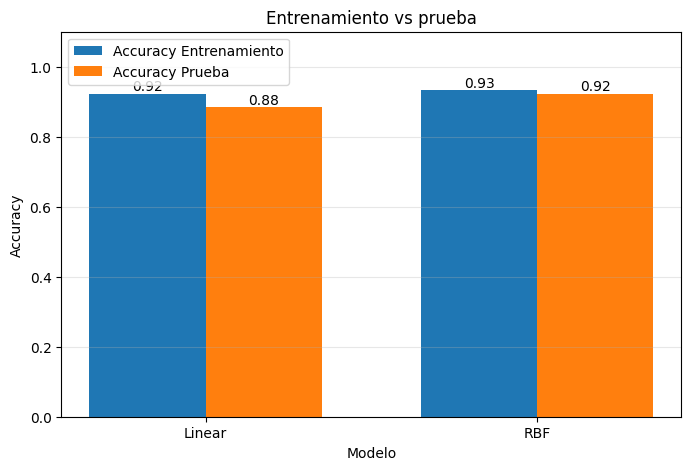

In [18]:
x = np.arange(len(df_final))
ancho = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - ancho / 2, df_final["Accuracy Entrenamiento"], ancho,
            label="Accuracy Entrenamiento")
b2 = ax.bar(x + ancho / 2, df_final["Accuracy Prueba"], ancho,
            label="Accuracy Prueba")

ax.bar_label(b1, fmt="%.2f")
ax.bar_label(b2, fmt="%.2f")
ax.set_xticks(x)
ax.set_xticklabels(df_final["Modelo"])
ax.set_ylim(0, 1.1)
ax.set_ylabel("Accuracy")
ax.set_xlabel("Modelo")
ax.set_title("Entrenamiento vs prueba")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.show()

### Preguntas para discusión

1. **¿Las clases parecen completamente separables?** No: hay traslape en la zona central del
   scatter, y ningún modelo llega al 100 % en prueba.
2. **¿Qué errores cometió el primer SVM?** La matriz de confusión muestra los falsos
   positivos y falsos negativos concretos; caen justo en la zona de traslape.
3. **¿Qué ocurrió al modificar C?** Con kernel lineal el accuracy de prueba se mantiene
   estable: el límite no es la penalización, es la forma recta de la frontera.
4. **¿Y gamma?** Con gamma alto el train sube y el test baja -> sobreajuste.
5. **¿Lineal vs RBF?** El RBF dobla la frontera y captura mejor la estructura real.
6. **¿Un mayor accuracy siempre significa un modelo mejor?** No. Hay que mirar la brecha
   train/test, el balance de clases y qué tipo de error cuesta más en el problema real.

## Paso 14 — Extensión opcional: 13 variables y 3 clases

Ahora se usa **todo** el dataset. Ya no es posible graficar la frontera, pero el modelo
aprovecha toda la información disponible.

In [19]:
X_full = df[wine.feature_names].values
y_full = df["target"].values

Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    X_full, y_full,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_full,
)

scaler_full = StandardScaler()
Xf_train_scaled = scaler_full.fit_transform(Xf_train)
Xf_test_scaled = scaler_full.transform(Xf_test)

print("Xf_train:", Xf_train.shape, "| Xf_test:", Xf_test.shape)
print("Clases en train:", np.bincount(yf_train))

Xf_train: (142, 13) | Xf_test: (36, 13)
Clases en train: [47 57 38]


In [20]:
# En multiclase las métricas necesitan un promedio: usamos "macro"
def metricas_multi(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }

filas = []
for cfg in configuraciones:
    modelo = SVC(**cfg).fit(Xf_train_scaled, yf_train)
    m_tr = metricas_multi(yf_train, modelo.predict(Xf_train_scaled))
    m_te = metricas_multi(yf_test, modelo.predict(Xf_test_scaled))
    filas.append({
        "kernel": cfg["kernel"],
        "C": cfg["C"],
        "gamma": cfg.get("gamma", "-"),
        "acc_train": m_tr["accuracy"],
        "acc_test": m_te["accuracy"],
        "f1_test": m_te["f1"],
        "brecha": m_tr["accuracy"] - m_te["accuracy"],
    })

df_full = pd.DataFrame(filas).sort_values("acc_test", ascending=False)
df_full.round(3)

,kernel,C,gamma,acc_train,acc_test,f1_test,brecha
0,linear,0.1,-,0.993,0.972,0.971,0.021
3,rbf,1.0,0.1,1.000,0.972,0.971,0.028
1,linear,1.0,-,1.000,0.944,0.945,0.056
2,linear,10.0,-,1.000,0.944,0.945,0.056
5,rbf,10.0,1,1.000,0.611,0.528,0.389
4,rbf,1.0,1,1.000,0.556,0.469,0.444


In [21]:
# Mejor configuración del bloque anterior, en detalle
mejor = df_full.iloc[0]
kwargs = {"kernel": mejor["kernel"], "C": mejor["C"]}
if mejor["gamma"] != "-":
    kwargs["gamma"] = mejor["gamma"]

modelo_full = SVC(**kwargs).fit(Xf_train_scaled, yf_train)
pred_full = modelo_full.predict(Xf_test_scaled)

print("Configuración:", kwargs)
print("\nMatriz de confusión (prueba, 3 clases):")
print(confusion_matrix(yf_test, pred_full))
print("\nReporte de clasificación:")
print(classification_report(yf_test, pred_full,
                            target_names=list(wine.target_names)))

Configuración: {'kernel': 'linear', 'C': np.float64(0.1)}

Matriz de confusión (prueba, 3 clases):
[[12  0  0]
 [ 0 14  0]
 [ 0  1  9]]

Reporte de clasificación:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



In [22]:
# Comparación final: 2 variables / 2 clases  vs  13 variables / 3 clases
resumen = pd.DataFrame({
    "Enfoque": ["2 variables, 2 clases (RBF C=1)",
                f"13 variables, 3 clases ({kwargs['kernel']} C={kwargs['C']})"],
    "Accuracy prueba": [m_te_rbf["accuracy"],
                        accuracy_score(yf_test, pred_full)],
    "Visualizable": ["Sí (2D)", "No"],
})
resumen.round(3)

,Enfoque,Accuracy prueba,Visualizable
0,"2 variables, 2 clases (RBF C=1)",0.923,Sí (2D)
1,"13 variables, 3 clases (linear C=0.1)",0.972,No


### Conclusiones

- **Escalar es obligatorio** en SVM, y el scaler se ajusta solo con entrenamiento.
- Con 2 variables, el kernel **RBF** supera al lineal (0.923 vs 0.885 en prueba) y además
  presenta menor brecha train/test.
- `C` y `gamma` son las dos perillas del sobreajuste: `gamma=10` lo evidencia claramente.
- Los **vectores de soporte** son la ventana al modelo: solo esos puntos definen la frontera.
- Al usar las 13 variables se recupera casi toda la señal del problema y el accuracy sube,
  al costo de perder la posibilidad de visualizar la frontera.